# Federated Denoising Diffusion Probabilistic Model (FedDDPM)
## Privacy-Preserving Chest X-Ray Synthesis Across Non-IID Hospital Data

## Step 0 — Environment Setup

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pytorch-fid', '--quiet'], check=True)

import torch, torchvision, math, os, copy, time, subprocess
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Kaggle paths
KAGGLE_INPUT = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
SAVE_PATH    = '/kaggle/working/FedDDPM'
os.makedirs(SAVE_PATH, exist_ok=True)

print('Input path :', KAGGLE_INPUT)
print('Save path  :', SAVE_PATH)
print('CUDA available:', torch.cuda.is_available())
print('PyTorch version:', torch.__version__)

# Confirming dataset is accessible
for split in ['train', 'val', 'test']:
    p = os.path.join(KAGGLE_INPUT, split)
    exists = os.path.isdir(p)
    print(f'  {split:5s} split found: {exists}', '' if exists else '  ← Add dataset via + Add Data')

Input path : /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
Save path  : /kaggle/working/FedDDPM
CUDA available: True
PyTorch version: 2.10.0+cu128
  train split found: True 
  val   split found: True 
  test  split found: True 


In [ ]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))
    print('VRAM  :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


## Step 1 — Dataset Loading & Preprocessing

In [ ]:
# Transforms
IMG_SIZE = 96

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [0,1] -> [-1,1]
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

from torchvision.datasets import ImageFolder

dataset      = ImageFolder(root=os.path.join(KAGGLE_INPUT, 'train'), transform=train_transform)
val_dataset  = ImageFolder(root=os.path.join(KAGGLE_INPUT, 'val'),   transform=eval_transform)
test_dataset = ImageFolder(root=os.path.join(KAGGLE_INPUT, 'test'),  transform=eval_transform)

# 2 CPU workers per GPU session
NUM_WORKERS = 2
dataloader = DataLoader(dataset, batch_size=32, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {len(dataset):,} images | Classes: {dataset.classes}')
print(f'Val   : {len(val_dataset):,} images')
print(f'Test  : {len(test_dataset):,} images')

Train : 5,216 images | Classes: ['NORMAL', 'PNEUMONIA']
Val   : 16 images
Test  : 624 images


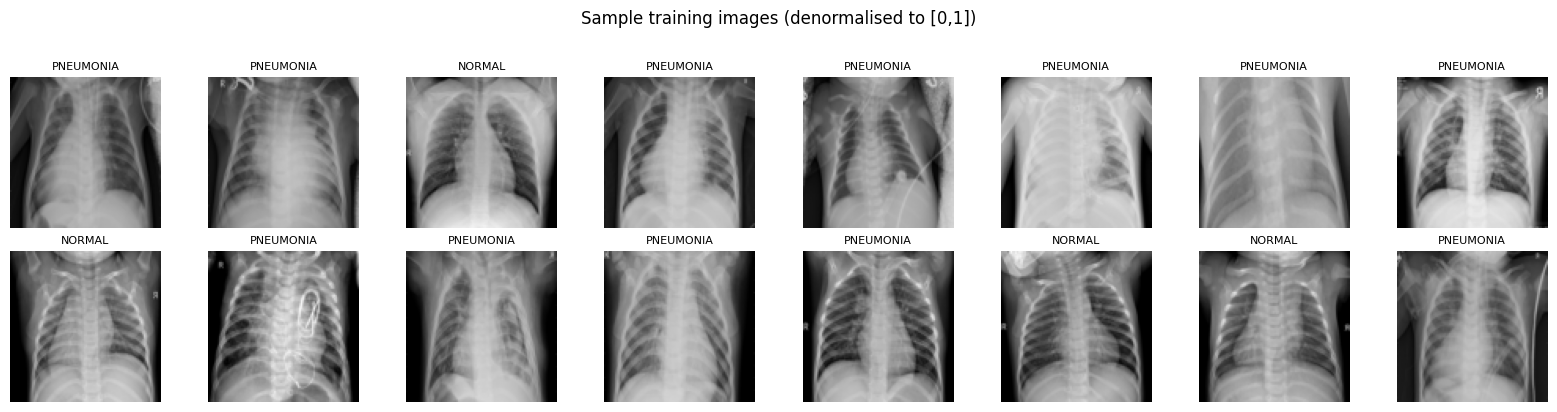

Tensor shape: torch.Size([32, 1, 96, 96])  Range: [-1.00, 0.97]


In [ ]:
# Visualizing training samples
images, labels = next(iter(dataloader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = (images[i].squeeze().numpy() + 1) / 2
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(dataset.classes[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample training images (denormalised to [0,1])', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Tensor shape: {images.shape}  Range: [{images.min():.2f}, {images.max():.2f}]')

## Step 2 — Non-IID Federated Split (5 Hospitals)

In [ ]:
# Separate by class
targets       = np.array(dataset.targets)
normal_idx    = np.where(targets == 0)[0]
pneumonia_idx = np.where(targets == 1)[0]

rng = np.random.default_rng(SEED)
rng.shuffle(normal_idx)
rng.shuffle(pneumonia_idx)

n_splits         = 5
normal_splits    = np.array_split(normal_idx,    n_splits)
pneumonia_splits = np.array_split(pneumonia_idx, n_splits)

# Deliberate label skew across hospitals
# H1: Normal-heavy  H2,H4,H5: Pneumonia-heavy  H3: Balanced
clients = [
    np.concatenate([normal_splits[0],        pneumonia_splits[0][:80]]),   # H1
    np.concatenate([normal_splits[1][:268],  pneumonia_splits[1]]),        # H2
    np.concatenate([normal_splits[2],        pneumonia_splits[2][:268]]),  # H3
    np.concatenate([normal_splits[3][:200],  pneumonia_splits[3]]),        # H4
    np.concatenate([normal_splits[4],        pneumonia_splits[4][:775]]),  # H5
]

print(f'  {'Hospital':^10} {'Normal':>8} {'Pneumonia':>10} {'% Pneumonia':>12}')
print('  ' + '─' * 43)
for i, idxs in enumerate(clients):
    lbl = targets[idxs]
    n0, n1 = int(np.sum(lbl==0)), int(np.sum(lbl==1))
    print(f'  Hospital {i+1}   {n0:>8}  {n1:>10}  {100*n1/(n0+n1):>11.1f}%')

   Hospital    Normal  Pneumonia  % Pneumonia
  ───────────────────────────────────────────
  Hospital 1        269          80         22.9%
  Hospital 2        268         775         74.3%
  Hospital 3        268         268         50.0%
  Hospital 4        200         775         79.5%
  Hospital 5        268         775         74.3%


Client sizes: [349, 1043, 536, 975, 1043] | Total: 3946


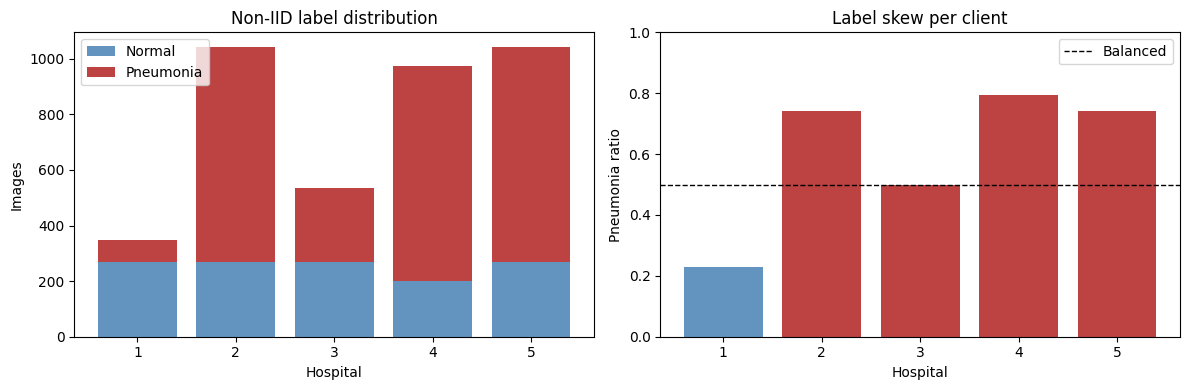

In [ ]:
# Build DataLoaders
client_loaders = []
client_sizes   = []
for idxs in clients:
    subset = Subset(dataset, idxs)
    loader = DataLoader(subset, batch_size=32, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)
    client_loaders.append(loader)
    client_sizes.append(len(idxs))

print('Client sizes:', client_sizes, '| Total:', sum(client_sizes))

# Distribution plot
ratios    = [np.mean(targets[idxs]==1) for idxs in clients]
counts_n  = [int(np.sum(targets[idxs]==0)) for idxs in clients]
counts_p  = [int(np.sum(targets[idxs]==1)) for idxs in clients]
x = np.arange(1, 6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x, counts_n, label='Normal',    color='steelblue', alpha=0.85)
axes[0].bar(x, counts_p, bottom=counts_n,   label='Pneumonia', color='firebrick', alpha=0.85)
axes[0].set_xlabel('Hospital'); axes[0].set_ylabel('Images')
axes[0].set_title('Non-IID label distribution'); axes[0].legend(); axes[0].set_xticks(x)

axes[1].bar(x, ratios, color=['steelblue' if r < 0.5 else 'firebrick' for r in ratios], alpha=0.85)
axes[1].axhline(0.5, color='k', linestyle='--', linewidth=1, label='Balanced')
axes[1].set_xlabel('Hospital'); axes[1].set_ylabel('Pneumonia ratio')
axes[1].set_title('Label skew per client'); axes[1].set_xticks(x)
axes[1].set_ylim(0, 1); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/non_iid_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Diffusion Schedule (Cosine, T=1000)

T=1000 | beta range: [0.000100, 0.020000]
alpha_hat range: [0.003195, 0.9999]


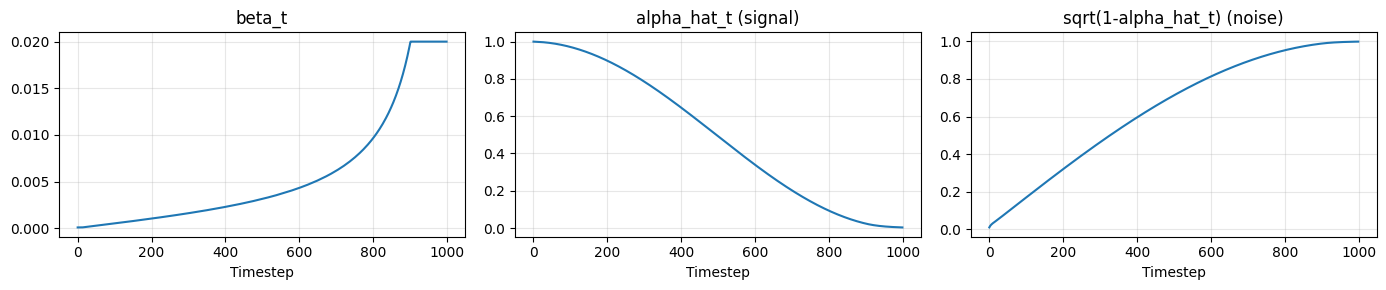

In [ ]:
T = 1000

def cosine_beta_schedule(T: int, s: float = 0.008) -> torch.Tensor:
    """Cosine noise schedule (Nichol & Dhariwal, 2021)."""
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.02)

betas     = cosine_beta_schedule(T).to(DEVICE)
alphas    = (1.0 - betas).to(DEVICE)
alpha_hat = torch.cumprod(alphas, dim=0).to(DEVICE)

sqrt_alpha_hat           = torch.sqrt(alpha_hat)
sqrt_one_minus_alpha_hat = torch.sqrt(1.0 - alpha_hat)

# Posterior variance (clipped) used during reverse diffusion
alpha_hat_prev = torch.cat([torch.tensor([1.0], device=DEVICE), alpha_hat[:-1]])
posterior_var  = betas * (1.0 - alpha_hat_prev) / (1.0 - alpha_hat)

print(f'T={T} | beta range: [{betas.min():.6f}, {betas.max():.6f}]')
print(f'alpha_hat range: [{alpha_hat[-1]:.6f}, {alpha_hat[0]:.4f}]')

# Schedule visualisation
t_axis = np.arange(T)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(t_axis, betas.cpu());                    axes[0].set_title('beta_t')
axes[1].plot(t_axis, alpha_hat.cpu());                axes[1].set_title('alpha_hat_t (signal)')
axes[2].plot(t_axis, sqrt_one_minus_alpha_hat.cpu()); axes[2].set_title('sqrt(1-alpha_hat_t) (noise)')
for ax in axes: ax.set_xlabel('Timestep'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/diffusion_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

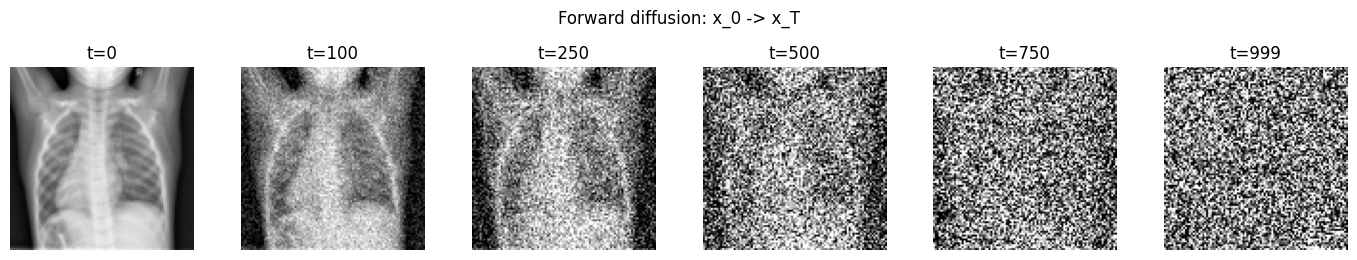

In [ ]:
def forward_diffusion(x0: torch.Tensor, t: torch.Tensor):
    """q(x_t | x_0) = N(sqrt(alpha_hat_t)*x_0, (1-alpha_hat_t)*I)"""
    noise  = torch.randn_like(x0)
    s_ah   = sqrt_alpha_hat[t].view(-1, 1, 1, 1)
    s_1mah = sqrt_one_minus_alpha_hat[t].view(-1, 1, 1, 1)
    return s_ah * x0 + s_1mah * noise, noise

# Sanity check: visualise forward diffusion
img0, _ = dataset[0]
img0 = img0.unsqueeze(0).to(DEVICE)
timesteps_vis = [0, 100, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps_vis), figsize=(14, 2.5))
for ax, t_val in zip(axes, timesteps_vis):
    xt, _ = forward_diffusion(img0, torch.tensor([t_val], device=DEVICE).long())
    ax.imshow(np.clip((xt.squeeze().cpu().numpy() + 1) / 2, 0, 1), cmap='gray')
    ax.set_title(f't={t_val}'); ax.axis('off')
plt.suptitle('Forward diffusion: x_0 -> x_T', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/forward_diffusion_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — UNet Architecture

In [ ]:
def get_timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    """Sinusoidal positional embedding for timestep conditioning."""
    assert dim % 2 == 0
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=timesteps.device) * -emb)
    emb = timesteps.float().unsqueeze(1) * emb.unsqueeze(0)
    return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int = 256):
        super().__init__()
        self.norm1     = nn.GroupNorm(8, in_ch)
        self.conv1     = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.skip      = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act       = nn.SiLU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, in_ch: int = 1, base_ch: int = 64, time_dim: int = 256):
        super().__init__()
        self.time_dim = time_dim
        ch = [base_ch, base_ch*2, base_ch*4, base_ch*4]  # [64,128,256,256]

        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )

        # Encoder
        self.enc_in = nn.Conv2d(in_ch, ch[0], 3, padding=1)
        self.enc1   = ResidualBlock(ch[0], ch[0], time_dim)                   # 96x96
        self.down1  = nn.Conv2d(ch[0], ch[0], 4, stride=2, padding=1)        # 48x48
        self.enc2   = ResidualBlock(ch[0], ch[1], time_dim)                   # 48x48
        self.down2  = nn.Conv2d(ch[1], ch[1], 4, stride=2, padding=1)        # 24x24
        self.enc3   = ResidualBlock(ch[1], ch[2], time_dim)                   # 24x24
        self.down3  = nn.Conv2d(ch[2], ch[2], 4, stride=2, padding=1)        # 12x12

        # Bottleneck
        self.mid1 = ResidualBlock(ch[2], ch[3], time_dim)
        self.mid2 = ResidualBlock(ch[3], ch[3], time_dim)

        # Decoder (each up block doubles spatial dims; cat with matching encoder output)
        self.up3  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ch[3], ch[2], 3, padding=1)
        )
        self.dec3 = ResidualBlock(ch[2] + ch[2], ch[2], time_dim)            # skip from enc3

        self.up2  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ch[2], ch[1], 3, padding=1)
        )
        self.dec2 = ResidualBlock(ch[1] + ch[1], ch[1], time_dim)            # skip from enc2

        self.up1  = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ch[1], ch[0], 3, padding=1)
        )
        self.dec1 = ResidualBlock(ch[0] + ch[0], ch[0], time_dim)            # skip from enc1

        self.out_norm = nn.GroupNorm(8, ch[0])
        self.out_conv = nn.Conv2d(ch[0], in_ch, 3, padding=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(get_timestep_embedding(t, self.time_dim))

        x0 = self.enc_in(x)                                                   # [B,64,96,96]
        e1 = self.enc1(x0, t_emb)                                             # [B,64,96,96]
        e2 = self.enc2(self.down1(e1), t_emb)                                 # [B,128,48,48]
        e3 = self.enc3(self.down2(e2), t_emb)                                 # [B,256,24,24]
        m  = self.mid2(self.mid1(self.down3(e3), t_emb), t_emb)              # [B,256,12,12]

        d3 = self.dec3(torch.cat([self.up3(m),  e3], dim=1), t_emb)          # [B,256,24,24]
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)          # [B,128,48,48]
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)          # [B,64,96,96]

        return self.out_conv(nn.functional.silu(self.out_norm(d1)))


# Architecture sanity check
with torch.no_grad():
    _m = UNet().to(DEVICE)
    _x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _t = torch.randint(0, T, (2,), device=DEVICE).long()
    _y = _m(_x, _t)
    params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f'UNet OK: {_x.shape} -> {_y.shape} | Params: {params:,}')
    del _m, _x, _t, _y
    torch.cuda.empty_cache()

UNet OK: torch.Size([2, 1, 96, 96]) -> torch.Size([2, 1, 96, 96]) | Params: 9,045,889


In [ ]:
# Exponential Moving Average of model weights
class EMA:
    def __init__(self, model: nn.Module, beta: float = 0.9999, warmup_steps: int = 500):
        self.beta         = beta
        self.warmup_steps = warmup_steps
        self.step_count   = 0
        self.ema_model    = copy.deepcopy(model)
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    def update(self, model: nn.Module):
        self.step_count += 1
        effective_beta = min(self.beta, (1 + self.step_count) / (10 + self.step_count))
        with torch.no_grad():
            for ep, mp in zip(self.ema_model.parameters(), model.parameters()):
                ep.data.mul_(effective_beta).add_(mp.data, alpha=1 - effective_beta)

## Step 5 — Sampling (DDPM Reverse Diffusion)

In [ ]:
@torch.no_grad()
def sample_ddpm(model: nn.Module, n: int = 4,
                img_size: int = IMG_SIZE,    # uses the global IMG_SIZE; original hardcoded 64
                progress: bool = True) -> torch.Tensor:
    """Full DDPM reverse diffusion: x_T -> x_0 using clipped posterior variance."""
    model.eval()
    x = torch.randn(n, 1, img_size, img_size, device=DEVICE)

    iterator = tqdm(reversed(range(1, T)), desc='Sampling', total=T-1) if progress else reversed(range(1, T))
    for t_val in iterator:
        t_batch = torch.full((n,), t_val, device=DEVICE, dtype=torch.long)
        pred_noise = model(x, t_batch)

        alpha_t     = alphas[t_val]
        alpha_hat_t = alpha_hat[t_val]

        x = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_hat_t)) * pred_noise
        )
        if t_val > 1:
            x = x + torch.sqrt(posterior_var[t_val].clamp(min=1e-20)) * torch.randn_like(x)

    return x.clamp(-1, 1)


def visualise_samples(samples: torch.Tensor, title: str = 'Generated samples',
                      save_name: str = None, nrow: int = 8):
    from torchvision.utils import make_grid
    grid = make_grid(samples, nrow=nrow, normalize=True, value_range=(-1, 1))
    h = math.ceil(len(samples) / nrow)
    fig, ax = plt.subplots(figsize=(nrow * 1.5, h * 1.5))
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.axis('off'); ax.set_title(title)
    plt.tight_layout()
    if save_name:
        plt.savefig(f'{SAVE_PATH}/{save_name}', dpi=150, bbox_inches='tight')
    plt.show()

## Step 6 — Centralized DDPM Baseline

In [ ]:
model     = UNet().to(DEVICE)
ema       = EMA(model, beta=0.9999, warmup_steps=500)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-5)
criterion = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters : {n_params:,}')
print(f'Optimizer  : AdamW(lr=2e-4, wd=1e-4)')
print(f'Scheduler  : CosineAnnealing(T_max=40, eta_min=1e-5)')

Parameters : 9,045,889
Optimizer  : AdamW(lr=2e-4, wd=1e-4)
Scheduler  : CosineAnnealing(T_max=40, eta_min=1e-5)


In [ ]:
CENTRALIZED_EPOCHS = 40
loss_history = []
best_loss    = float('inf')
train_start  = time.time()

for epoch in range(CENTRALIZED_EPOCHS):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1:02d}/{CENTRALIZED_EPOCHS}', leave=False)

    for images, _ in pbar:
        images = images.to(DEVICE)
        t = torch.randint(0, T, (images.size(0),), device=DEVICE).long()
        xt, noise = forward_diffusion(images, t)

        loss = criterion(model(xt, t), noise)
        optimizer.zero_grad()
        loss.backward()
        # clip BEFORE optimizer.step() — original had these two lines reversed
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        ema.update(model)

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss /= len(dataloader)
    loss_history.append(epoch_loss)
    scheduler.step()

    saved = ''
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'ema_state':   ema.ema_model.state_dict(),
            'optimizer':   optimizer.state_dict(),
            'loss':        best_loss,
        }, f'{SAVE_PATH}/best_centralized.pth')
        saved = '  [saved]'

    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = (time.time() - train_start) / 60
        lr_now  = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1:02d} | loss={epoch_loss:.5f} | lr={lr_now:.2e} | {elapsed:.1f}min{saved}')

print(f'\nCentralized training done. Best loss: {best_loss:.5f}')

Epoch 01 | loss=2.68224 | lr=2.00e-04 | 1.0min  [saved]


Epoch 05 | loss=0.04797 | lr=1.93e-04 | 5.3min  [saved]


Epoch 10 | loss=0.03998 | lr=1.72e-04 | 10.7min


Epoch 15 | loss=0.03616 | lr=1.41e-04 | 16.2min


Epoch 20 | loss=0.03415 | lr=1.05e-04 | 21.6min


Epoch 25 | loss=0.03267 | lr=6.86e-05 | 27.0min


Epoch 30 | loss=0.03327 | lr=3.78e-05 | 32.3min


Epoch 35 | loss=0.03174 | lr=1.72e-05 | 37.7min


Epoch 40 | loss=0.03167 | lr=1.00e-05 | 43.1min

Centralized training done. Best loss: 0.03096


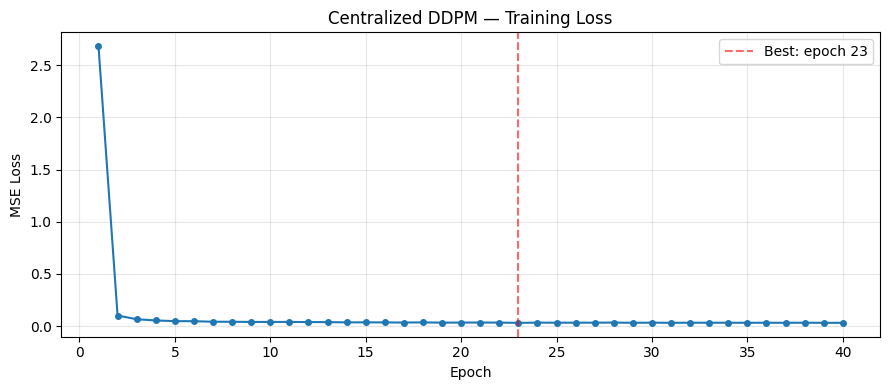

In [ ]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(loss_history)+1), loss_history, marker='o', ms=4, linewidth=1.5)
best_ep = int(np.argmin(loss_history)) + 1
ax.axvline(best_ep, color='r', linestyle='--', alpha=0.6, label=f'Best: epoch {best_ep}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Centralized DDPM — Training Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/centralized_loss.png', dpi=150, bbox_inches='tight')
plt.show()

Loaded best centralized model (epoch 23, loss 0.03096)


Sampling: 100%|██████████| 999/999 [01:03<00:00, 15.69it/s]


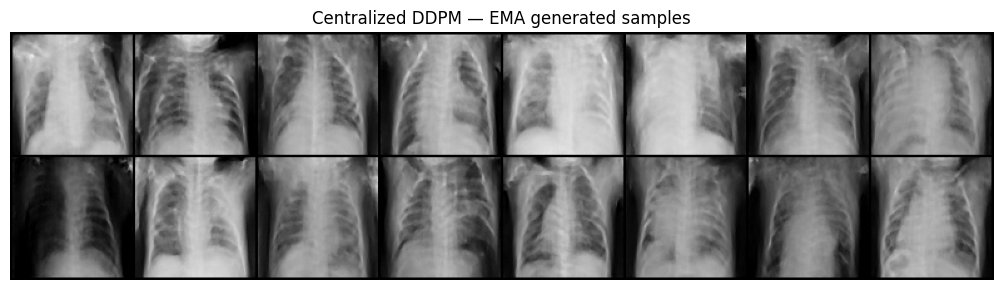

In [ ]:
# Load best checkpoint and generate samples
ckpt = torch.load(f'{SAVE_PATH}/best_centralized.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
ema.ema_model.load_state_dict(ckpt['ema_state'])
print(f'Loaded best centralized model (epoch {ckpt["epoch"]+1}, loss {ckpt["loss"]:.5f})')

centralized_samples = sample_ddpm(ema.ema_model, n=16, progress=True)
visualise_samples(centralized_samples,
                  title='Centralized DDPM — EMA generated samples',
                  save_name='centralized_generated.png', nrow=8)

from torchvision.utils import save_image
save_image(centralized_samples, f'{SAVE_PATH}/centralized_generated_grid.png',
           normalize=True, nrow=8)

## Step 7 — Federated DDPM via Weighted FedAvg

In [ ]:
def train_local(global_state_dict: dict, loader: DataLoader,
                local_epochs: int = 2, lr: float = 1e-4):
    """Train one client model copy; return weights and average MSE loss."""
    local_model = UNet().to(DEVICE)
    local_model.load_state_dict(global_state_dict)
    local_model.train()

    opt  = torch.optim.AdamW(local_model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.MSELoss()
    total_loss, n_steps = 0.0, 0

    for _ in range(local_epochs):
        for images, _ in loader:
            images = images.to(DEVICE)
            t = torch.randint(0, T, (images.size(0),), device=DEVICE).long()
            xt, noise = forward_diffusion(images, t)
            loss = crit(local_model(xt, t), noise)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), 1.0)
            opt.step()

            total_loss += loss.item()
            n_steps += 1

    return local_model.state_dict(), total_loss / n_steps


def fedavg_weighted(global_model: nn.Module,
                    client_states: list,
                    client_sizes: list) -> nn.Module:
    total   = sum(client_sizes)
    weights = [s / total for s in client_sizes]
    new_dict = global_model.state_dict()
    for key in new_dict.keys():
        new_dict[key] = sum(
            w * client_states[i][key].float()
            for i, w in enumerate(weights)
        )
    global_model.load_state_dict(new_dict)
    return global_model

In [ ]:
FED_ROUNDS   = 10   # original: 5
LOCAL_EPOCHS = 2    # original: 1
LOCAL_LR     = 5e-5

# Warm-start from best centralized model
global_model = UNet().to(DEVICE)
global_model.load_state_dict(
    torch.load(f'{SAVE_PATH}/best_centralized.pth', map_location=DEVICE)['model_state']
)
print('Federated model initialised from best centralized checkpoint.')

fed_loss_history      = []
fed_loss_per_client   = [[] for _ in range(len(clients))]
best_fed_loss         = float('inf')

for r in range(FED_ROUNDS):
    t0 = time.time()
    print(f'\n[Round {r+1}/{FED_ROUNDS}]')

    client_states = []
    round_loss    = 0.0

    for i, loader in enumerate(client_loaders):
        state, loss = train_local(
            global_model.state_dict(), loader,
            local_epochs=LOCAL_EPOCHS, lr=LOCAL_LR
        )
        client_states.append(state)
        round_loss += loss
        fed_loss_per_client[i].append(loss)
        print(f'  Hospital {i+1}: loss={loss:.5f}')

    round_loss /= len(client_loaders)
    fed_loss_history.append(round_loss)
    global_model = fedavg_weighted(global_model, client_states, client_sizes)

    torch.save(global_model.state_dict(),
               f'{SAVE_PATH}/fed_model_round_{r+1:02d}.pth')

    saved = ''
    if round_loss < best_fed_loss:
        best_fed_loss = round_loss
        torch.save(global_model.state_dict(), f'{SAVE_PATH}/best_federated.pth')
        saved = '  [saved]'

    print(f'  Avg loss={round_loss:.5f} | {time.time()-t0:.1f}s{saved}')

print(f'\nFederated training done. Best loss: {best_fed_loss:.5f}')

Federated model initialised from best centralized checkpoint.

[Round 1/10]
  Hospital 1: loss=0.03982
  Hospital 2: loss=0.03260
  Hospital 3: loss=0.03670
  Hospital 4: loss=0.03348
  Hospital 5: loss=0.03247
  Avg loss=0.03501 | 106.7s  [saved]

[Round 2/10]
  Hospital 1: loss=0.04403
  Hospital 2: loss=0.03339
  Hospital 3: loss=0.03384
  Hospital 4: loss=0.03310
  Hospital 5: loss=0.03433
  Avg loss=0.03574 | 106.7s

[Round 3/10]
  Hospital 1: loss=0.03997
  Hospital 2: loss=0.03265
  Hospital 3: loss=0.03134
  Hospital 4: loss=0.03387
  Hospital 5: loss=0.03589
  Avg loss=0.03474 | 107.2s  [saved]

[Round 4/10]
  Hospital 1: loss=0.04401
  Hospital 2: loss=0.03388
  Hospital 3: loss=0.03729
  Hospital 4: loss=0.03276
  Hospital 5: loss=0.03321
  Avg loss=0.03623 | 110.2s

[Round 5/10]
  Hospital 1: loss=0.03996
  Hospital 2: loss=0.03207
  Hospital 3: loss=0.03490
  Hospital 4: loss=0.03318
  Hospital 5: loss=0.03228
  Avg loss=0.03448 | 107.6s  [saved]

[Round 6/10]
  Hospital 1

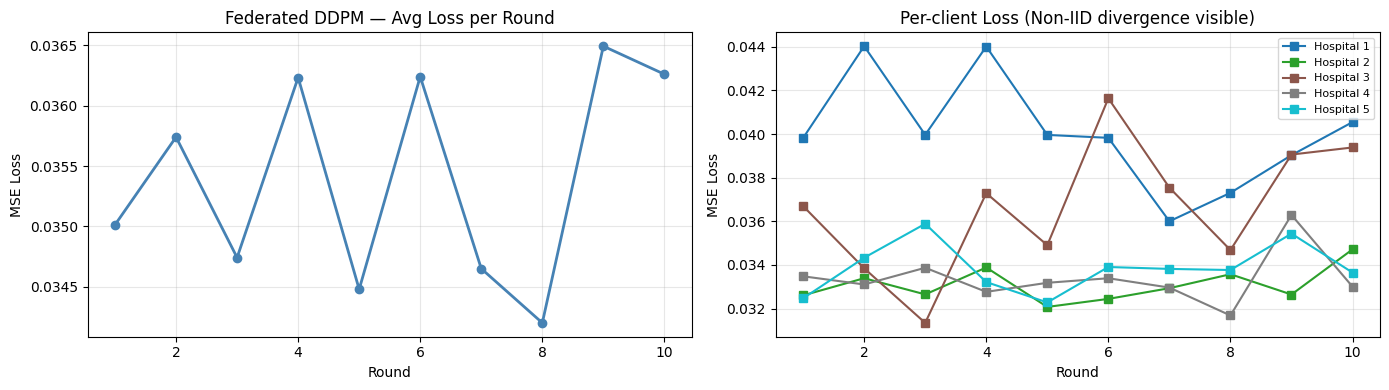

In [ ]:
# Federated loss plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, len(fed_loss_history)+1), fed_loss_history,
             marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Federated DDPM — Avg Loss per Round'); axes[0].grid(alpha=0.3)

colors = plt.cm.tab10(np.linspace(0, 1, len(clients)))
for i, (h_losses, c) in enumerate(zip(fed_loss_per_client, colors)):
    axes[1].plot(range(1, len(h_losses)+1), h_losses,
                 marker='s', linewidth=1.5, color=c, label=f'Hospital {i+1}')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Per-client Loss (Non-IID divergence visible)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/federated_loss.png', dpi=150, bbox_inches='tight')
plt.show()

Sampling: 100%|██████████| 999/999 [01:03<00:00, 15.73it/s]


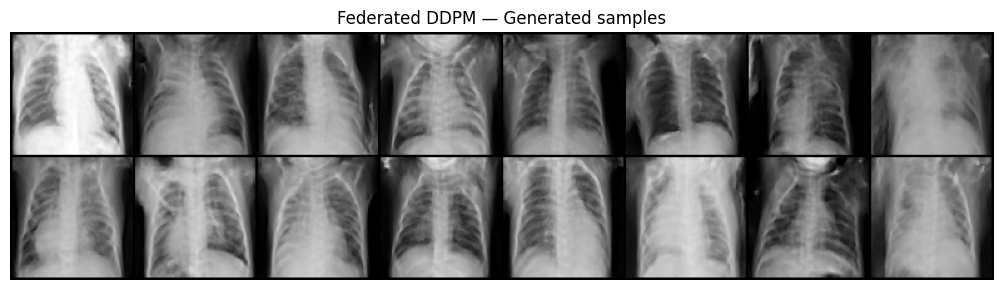

In [ ]:
# Generate federated samples
global_model.load_state_dict(
    torch.load(f'{SAVE_PATH}/best_federated.pth', map_location=DEVICE)
)
global_model.eval()

fed_samples = sample_ddpm(global_model, n=16, progress=True)
visualise_samples(fed_samples, title='Federated DDPM — Generated samples',
                  save_name='federated_generated.png', nrow=8)

save_image(fed_samples, f'{SAVE_PATH}/federated_generated_grid.png',
           normalize=True, nrow=8)

## Step 8 — FID Score Evaluation

In [ ]:
from torchvision.utils import save_image as tv_save

# Kaggle /tmp has ~10GB free — safe for FID image sets
REAL_DIR = '/tmp/fid_real'
CENT_DIR = '/tmp/fid_centralized'
FED_DIR  = '/tmp/fid_federated'

N_FID     = 512    # 2048+ is better; 512 is faster for Kaggle GPU sessions
BATCH_FID = 16


def save_images_for_fid(model: nn.Module, n: int, batch_size: int, out_dir: str, desc: str = ''):
    """Generate n images and save as 3-channel PNGs for pytorch-fid."""
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    idx = 0
    for _ in tqdm(range(math.ceil(n / batch_size)), desc=f'Generating {desc}'):
        bs = min(batch_size, n - idx)
        samples    = sample_ddpm(model, n=bs, progress=False)
        samples_01 = ((samples + 1) / 2).clamp(0, 1)
        for img in samples_01.repeat(1, 3, 1, 1):   # grey -> RGB for FID InceptionV3
            tv_save(img, os.path.join(out_dir, f'{idx:05d}.png'))
            idx += 1
    print(f'  Saved {idx} images -> {out_dir}')


def save_real_images_for_fid(dataset, n: int, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    idxs = np.random.choice(len(dataset), n, replace=False)
    for i, idx in enumerate(tqdm(idxs, desc='Saving real images')):
        img, _ = dataset[idx]
        tv_save(((img + 1) / 2).clamp(0, 1).repeat(3, 1, 1),
                os.path.join(out_dir, f'{i:05d}.png'))
    print(f'  Saved {n} real images -> {out_dir}')


print('Preparing FID image sets...')
save_real_images_for_fid(test_dataset, N_FID, REAL_DIR)

cent_model = UNet().to(DEVICE)
cent_model.load_state_dict(
    torch.load(f'{SAVE_PATH}/best_centralized.pth', map_location=DEVICE)['ema_state']
)
save_images_for_fid(cent_model, N_FID, BATCH_FID, CENT_DIR, 'centralized')

fed_model = UNet().to(DEVICE)
fed_model.load_state_dict(
    torch.load(f'{SAVE_PATH}/best_federated.pth', map_location=DEVICE)
)
save_images_for_fid(fed_model, N_FID, BATCH_FID, FED_DIR, 'federated')

Preparing FID image sets...


Saving real images: 100%|██████████| 512/512 [00:12<00:00, 41.39it/s]


  Saved 512 real images -> /tmp/fid_real


Generating centralized: 100%|██████████| 32/32 [33:56<00:00, 63.65s/it]


  Saved 512 images -> /tmp/fid_centralized


Generating federated: 100%|██████████| 32/32 [33:50<00:00, 63.44s/it]

  Saved 512 images -> /tmp/fid_federated


In [ ]:
def compute_fid(real_dir: str, gen_dir: str) -> float:
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    result = subprocess.run(
        [sys.executable, '-m', 'pytorch_fid', real_dir, gen_dir,
         '--device', dev, '--dims', '2048'],
        capture_output=True, text=True
    )
    output = result.stdout + result.stderr
    for line in output.splitlines():
        if 'FID' in line:
            try:
                return float(line.split(':')[-1].strip())
            except ValueError:
                pass
    print('FID raw output:\n', output)   # debug if parsing fails
    return float('nan')


fid_centralized = compute_fid(REAL_DIR, CENT_DIR)
fid_federated   = compute_fid(REAL_DIR, FED_DIR)

print('\n' + '=' * 42)
print(f'  FID  Centralized DDPM : {fid_centralized:.2f}')
print(f'  FID  Federated DDPM   : {fid_federated:.2f}')
print(f'  Delta (Fed - Cent)    : {fid_federated - fid_centralized:+.2f}')
print('=' * 42)


  FID  Centralized DDPM : 178.62
  FID  Federated DDPM   : 153.99
  Delta (Fed - Cent)    : -24.63


## Step 9 — Side-by-Side Visual Comparison

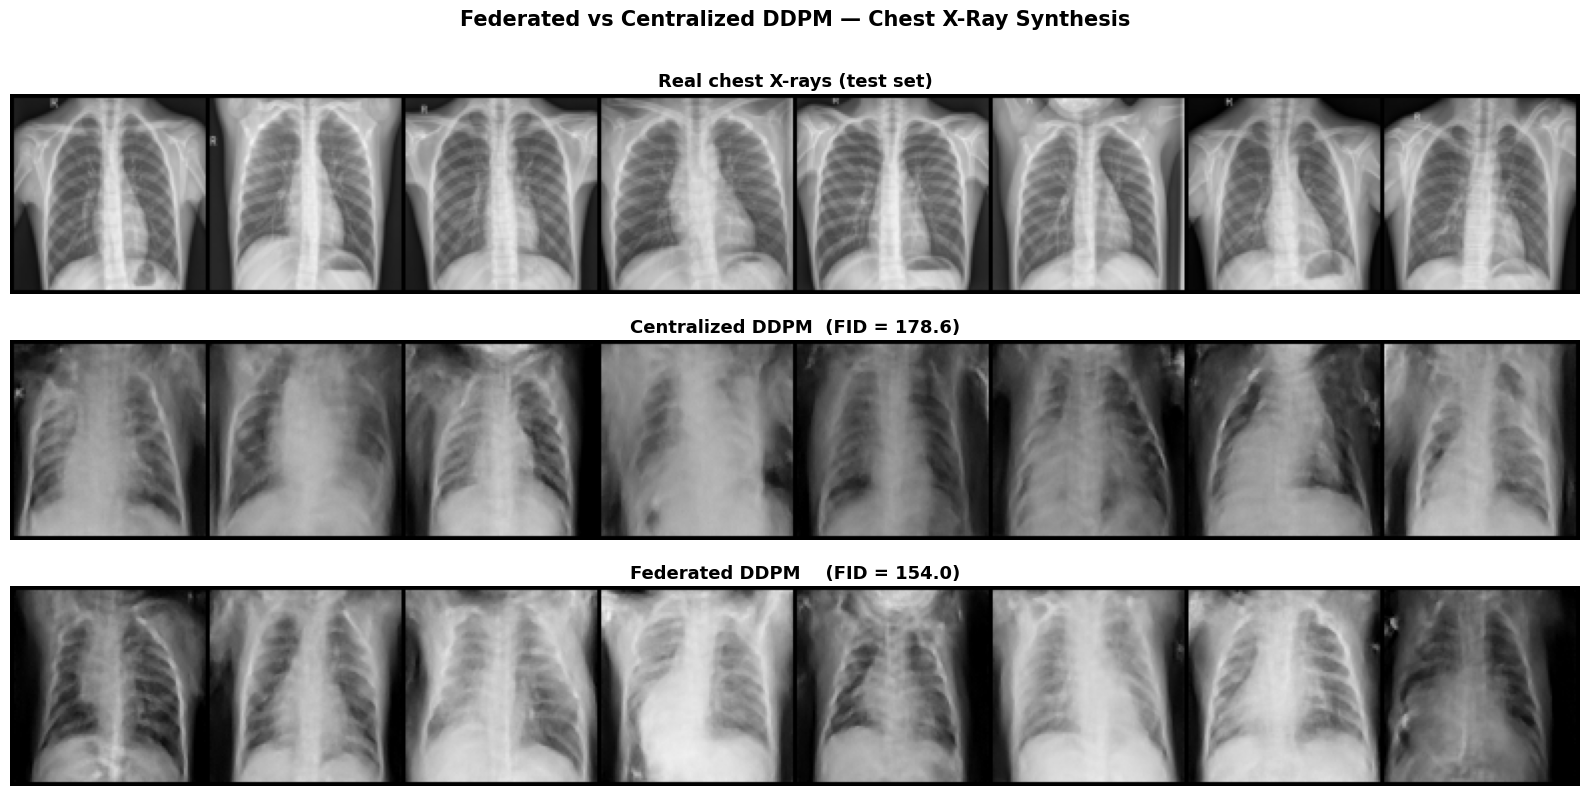

Comparison figure saved.


In [ ]:
from torchvision.utils import make_grid

n_show = 8
cent_samples = sample_ddpm(cent_model,  n=n_show, progress=False)
fed_s        = sample_ddpm(fed_model,   n=n_show, progress=False)
real_imgs    = torch.stack([test_dataset[i][0] for i in range(n_show)])

def grid_np(tensors, nrow):
    return make_grid(tensors, nrow=nrow, normalize=True,
                     value_range=(-1, 1)).permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(16, 8))
rows = [
    (real_imgs,    'Real chest X-rays (test set)'),
    (cent_samples, f'Centralized DDPM  (FID = {fid_centralized:.1f})'),
    (fed_s,        f'Federated DDPM    (FID = {fid_federated:.1f})'),
]
for ax, (imgs, label) in zip(axes, rows):
    ax.imshow(grid_np(imgs, n_show), cmap='gray')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Federated vs Centralized DDPM — Chest X-Ray Synthesis',
             y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/comparison_real_vs_generated.png', dpi=200, bbox_inches='tight')
plt.show()
print('Comparison figure saved.')

## Step 10 — Summary & Output Files

In [ ]:
print('=' * 55)
print('  FedDDPM — Summary')
print('=' * 55)
print(f'  Dataset         : Chest X-Ray (5216 train images)')
print(f'  Image size      : {IMG_SIZE}x{IMG_SIZE} grayscale')
print(f'  Diffusion steps : T={T} (cosine schedule)')
print(f'  UNet params     : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'  Centralized     : {CENTRALIZED_EPOCHS} epochs | best loss = {best_loss:.5f}')
print(f'  Federated       : {FED_ROUNDS} rounds x {LOCAL_EPOCHS} local epochs | best loss = {best_fed_loss:.5f}')
print(f'  FID centralized : {fid_centralized:.2f}')
print(f'  FID federated   : {fid_federated:.2f}')
print('─' * 55)
print(f'  Output files in: {SAVE_PATH}')
for f in sorted(os.listdir(SAVE_PATH)):
    size_kb = os.path.getsize(os.path.join(SAVE_PATH, f)) // 1024
    print(f'    {f:45s} {size_kb:>6} KB')
print('=' * 55)
print()

  FedDDPM — Summary
  Dataset         : Chest X-Ray (5216 train images)
  Image size      : 96x96 grayscale
  Diffusion steps : T=1000 (cosine schedule)
  UNet params     : 9,045,889
  Centralized     : 40 epochs | best loss = 0.03096
  Federated       : 10 rounds x 2 local epochs | best loss = 0.03420
  FID centralized : 178.62
  FID federated   : 153.99
───────────────────────────────────────────────────────
  Output files in: /kaggle/working/FedDDPM
    best_centralized.pth                          141514 KB
    best_federated.pth                             35373 KB
    centralized_generated.png                        312 KB
    centralized_generated_grid.png                   129 KB
    centralized_loss.png                              37 KB
    comparison_real_vs_generated.png                 381 KB
    diffusion_schedule.png                            63 KB
    fed_model_round_01.pth                         35374 KB
    fed_model_round_02.pth                         35374 KB
   